# 🧱 Part 21: Evaluation: Measuring Model Behavior

> **Previous context**: Once a model can train and generate, we need evidence that it is actually better.
> **Goal for this part**: Build small evaluation examples and understand accuracy, LLM-as-Judge, win rates, radar charts, and RAGAS-style metrics.

Today we are solving one concrete confusion: what is the hidden mechanism behind this part of an LLM, and how can we rebuild it with small numbers before trusting a library?

## 0. Why evaluation is hard

A single score rarely captures all behavior. Models can be good at one task and weak at another.

## 1. Benchmark types

Multiple-choice tasks, open-ended judge tasks, safety checks, multilingual tests, and retrieval tasks measure different skills.

## 2. Pairwise comparison

Win-rate matrices compare model outputs directly. This is often more informative than isolated scores.

## 3. RAG evaluation

RAGAS-style metrics split the question into faithfulness, relevance, and context usage.

## How to use the code cells

Run the cells in order. The code is intentionally direct and small: each cell should expose one idea, print the key observation, and let you change a number to see what moves.

## Exercises

When a cell contains a TODO placeholder, fill it yourself and use the `assert` checks as feedback. You can ask an AI for hints, step-by-step reasoning, or a direction check, but avoid asking it to complete the exercise outright.

## Summary Checklist

- [ ] Evaluation must match the behavior you care about.
- [ ] LLM-as-Judge needs careful prompts and calibration.
- [ ] Pairwise and composite metrics reveal different model trade-offs.

Next, continue through the code cells for the Evaluation & Deployment part and inspect the printed observations.


In [1]:
import os, json, sys, subprocess
from pathlib import Path

print(f"Python: {sys.version.split()[0]}")

cwd = Path.cwd()
parts = list(cwd.parts)
if "notebooks-en" in parts:
    rel = Path(*parts[parts.index("notebooks-en"):])
    print(f"Working directory: {rel.as_posix()}")
else:
    print("Working directory: (unknown)")

# Check key dependencies
deps = {
    "openai": "OpenAI SDK",
    "datasets": "HuggingFace datasets",
}
for pkg, desc in deps.items():
    try:
        __import__(pkg)
        print(f"  [ok] {pkg} - {desc}")
    except ImportError:
        print(f"  [x] {pkg} - {desc} (pip install {pkg})")

# Check whether lm-eval CLI is available
try:
    result = subprocess.run(["lm_eval", "--help"], capture_output=True, text=True, timeout=10)
    if result.returncode == 0:
        print("  [ok] lm_eval CLI - lm-evaluation-harness")
    else:
        print("  [x] lm_eval CLI not installed (pip install lm-eval)")
except FileNotFoundError:
    print("  [x] lm_eval CLI not installed (pip install lm-eval)")

print()
print("Install missing packages:")
print("  pip install openai lm-eval datasets")


Python: 3.12.2
Working directory: notebooks-en/part5-production


  [ok] openai - OpenAI SDK
  [x] datasets - HuggingFace datasets (pip install datasets)
  [x] lm_eval CLI not installed (pip install lm-eval)

Install missing packages:
  pip install openai lm-eval datasets


## Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
```
2019-2021         2022-2023            2024-2025
  ↓                  ↓                     ↓
GLUE/SuperGLUE   MMLU/GSM8K         LLM-as-Judge
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|:---|
|Read the values printed above and connect them to the concept in this cell.| MMLU-Pro、GPQA | acc |Read the values printed above and connect them to the concept in this cell.|
|**mathreasoning**| GSM8K、MATH、AIME 2024 | exact_match |Read the values printed above and connect them to the concept in this cell.|
|**code**| HumanEval+、LiveCodeBench、SWE-bench | pass@k |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| IFEval、MT-Bench | strict_acc |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| AlpacaEval、Chatbot Arena | win_rate/Elo |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| TruthfulQA、Garak |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| Needle-in-Haystack、RULER | recall |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| CMMLU、C-Eval | acc |Read the values printed above and connect them to the concept in this cell.|
| **Agent** | SWE-bench、WebArena | success_rate |Read the values printed above and connect them to the concept in this cell.|

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.math: GSM8K + MATH + AIME 2024Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.

## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
```bash
git clone https://github.com/EleutherAI/lm-evaluation-harness.git
cd lm-evaluation-harness
pip install -e .
```

- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
```bash
git clone https://github.com/tatsu-lab/alpaca_eval.git
cd alpaca_eval
pip install -e .
```

- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
```bash
git clone https://github.com/lm-sys/FastChat.git
cd FastChat
pip install -e ".[eval]"
```

- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
```bash
pip install deepeval
```

- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|
|Read the values printed above and connect them to the concept in this cell.| lm-evaluation-harness |
|Read the values printed above and connect them to the concept in this cell.| AlpacaEval / FastChat MT-Bench |
|Read the values printed above and connect them to the concept in this cell.| DeepEval / Promptfoo |
|Read the values printed above and connect them to the concept in this cell.| Garak（NVIDIA） |
|**Agent evaluation**| SWE-bench + WebArena |

Read the values printed above and connect them to the concept in this cell.

In [2]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

REPOS = {
    "lm-evaluation-harness": "https://github.com/EleutherAI/lm-evaluation-harness.git",
    "alpaca_eval": "https://github.com/tatsu-lab/alpaca_eval.git",
    "FastChat": "https://github.com/lm-sys/FastChat.git",
}

repos_dir = Path.home() / "Code"  # Teaching note: follow this line to see the main step.

print('Read the values printed above and connect them to the concept in this cell.')
for name, url in REPOS.items():
    repo_path = repos_dir / name
    if repo_path.exists():
        print(f"[ok] {name}Read the values printed above and connect them to the concept in this cell.{repo_path}")
    else:
        print(f"[x] {name}Read the values printed above and connect them to the concept in this cell.")
        print(f"Read the values printed above and connect them to the concept in this cell.{url} {repo_path}")
        print(f"              cd {repo_path} && pip install -e .")
    print()

# Teaching note: follow this line to see the main step.
try:
    import lm_eval
    print(f"Read the values printed above and connect them to the concept in this cell.{lm_eval.__version__ if hasattr(lm_eval, '__version__') else 'unknown'}")
except ImportError:
    print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
[x] lm-evaluation-harnessRead the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.https://github.com/EleutherAI/lm-evaluation-harness.git /Users/sanbu/Code/lm-evaluation-harness
              cd /Users/sanbu/Code/lm-evaluation-harness && pip install -e .

[x] alpaca_evalRead the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.https://github.com/tatsu-lab/alpaca_eval.git /Users/sanbu/Code/alpaca_eval
              cd /Users/sanbu/Code/alpaca_eval && pip install -e .

[x] FastChatRead the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.https://github.com/lm-sys/FastChat.git /Users/sanbu/Code/FastChat
              cd /Users/sanbu/Code/F

## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
Exercise passed: you have understood this step.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
| `local-chat-completions` | `/v1/chat/completions` |Read the values printed above and connect them to the concept in this cell.|
| `local-completions` | `/v1/completions` |Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
OpenAI API → need API KeyRead the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Ollama              → http://localhost:11434/v1
Read the values printed above and connect them to the concept in this cell.SGLang              → http://localhost:30000/v1
```

Read the values printed above and connect them to the concept in this cell.

In [3]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

print('"=== OpenAI-Compatible API evaluation GSM8K ===\\n"')

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

api_configs = {
    "OpenAI": {
        "model": "gpt-4o-mini",
        "base_url": "https://api.openai.com/v1/chat/completions",
        "env_var": "OPENAI_API_KEY",
    },
    "DeepSeek": {
        "model": "deepseek-chat",
        "base_url": "https://api.deepseek.com/v1/chat/completions",
        "env_var": "DEEPSEEK_API_KEY",
    },
    'Read the values printed above and connect them to the concept in this cell.': {
        "model": "Qwen2.5-7B-Instruct",
        "base_url": "http://localhost:8000/v1/chat/completions",
        "env_var": None,  # Teaching note: follow this line to see the main step.
    },
    'Read the values printed above and connect them to the concept in this cell.': {
        "model": "llama3",
        "base_url": "http://localhost:11434/v1/chat/completions",
        "env_var": None,
    },
}

for name, config in api_configs.items():
    print(f"--- {name} ---")
    key_arg = ""
    if config["env_var"]:
        key_arg = f",token=${{{config['env_var']}}}"
    cmd = (
        f"lm_eval --model local-chat-completions \\\n"
        f"    --model_args model={config['model']},"
        f"base_url={config['base_url']},"
        f"num_concurrent=4,max_retries=3,tokenized_requests=False{key_arg} \\\n"
        f"    --tasks gsm8k \\\n"
        f"    --batch_size 8 \\\n"
        f"    --output_path ./eval_results/gsm8k_{name.lower().replace(' ', '_')}"
    )
    print(f"  {cmd}\n")

print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

"=== OpenAI-Compatible API evaluation GSM8K ===\n"
--- OpenAI ---
  lm_eval --model local-chat-completions \
    --model_args model=gpt-4o-mini,base_url=https://api.openai.com/v1/chat/completions,num_concurrent=4,max_retries=3,tokenized_requests=False,token=${OPENAI_API_KEY} \
    --tasks gsm8k \
    --batch_size 8 \
    --output_path ./eval_results/gsm8k_openai

--- DeepSeek ---
  lm_eval --model local-chat-completions \
    --model_args model=deepseek-chat,base_url=https://api.deepseek.com/v1/chat/completions,num_concurrent=4,max_retries=3,tokenized_requests=False,token=${DEEPSEEK_API_KEY} \
    --tasks gsm8k \
    --batch_size 8 \
    --output_path ./eval_results/gsm8k_deepseek

--- Read the values printed above and connect them to the concept in this cell. ---
  lm_eval --model local-chat-completions \
    --model_args model=llama3,base_url=http://localhost:11434/v1/chat/completions,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks gsm8k \
    --batch_size 8 \
 

In [4]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

print('"=== OpenAI-Compatible API evaluation MMLU ===\\n"')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

mmu_configs = {
    "OpenAI": {
        "model": "gpt-4o-mini",
        "base_url": "https://api.openai.com/v1/completions",
        "env_var": "OPENAI_API_KEY",
        "note": 'Read the values printed above and connect them to the concept in this cell.',
    },
    'Read the values printed above and connect them to the concept in this cell.': {
        "model": "Qwen2.5-7B-Instruct",
        "base_url": "http://localhost:8000/v1/completions",
        "env_var": None,
        "note": 'Read the values printed above and connect them to the concept in this cell.',
    },
    "DeepSeek": {
        "model": "deepseek-chat",
        "base_url": "https://api.deepseek.com/v1/completions",
        "env_var": "DEEPSEEK_API_KEY",
        "note": 'Read the values printed above and connect them to the concept in this cell.',
    },
}

for name, config in mmu_configs.items():
    print(f"--- {name} ---")
    print(f"  {config['note']}")
    key_arg = ""
    if config["env_var"]:
        key_arg = f",token=${{{config['env_var']}}}"
    cmd = (
        f"lm_eval --model local-completions \\\n"
        f"    --model_args model={config['model']},"
        f"base_url={config['base_url']},"
        f"num_concurrent=4,max_retries=3,tokenized_requests=False{key_arg} \\\n"
        f"    --tasks mmlu \\\n"
        f"    --batch_size 16 \\\n"
        f"    --output_path ./eval_results/mmlu"
    )
    print(f"  {cmd}\n")

print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

"=== OpenAI-Compatible API evaluation MMLU ===\n"
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
--- OpenAI ---
  Read the values printed above and connect them to the concept in this cell.
  lm_eval --model local-completions \
    --model_args model=gpt-4o-mini,base_url=https://api.openai.com/v1/completions,num_concurrent=4,max_retries=3,tokenized_requests=False,token=${OPENAI_API_KEY} \
    --tasks mmlu \
    --batch_size 16 \
    --output_path ./eval_results/mmlu

--- Read the values printed above and connect them to the concept in this cell. ---
  Read the values printed above and connect them to the concept in this cell.
  lm_eval --model local-completions \
    --model_args model=Qwen2.5-7B-Instruct,base_url=http://localhost:8000/v1/completions,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks mmlu \
    --batch_size 16 \
    --output_path ./eval_results/mm

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [5]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')

try:
    from lm_eval import simple_evaluate
    from lm_eval.models.openai_completions import OpenaiCompletionsLM
    HAS_API = True
    print('Read the values printed above and connect them to the concept in this cell.')
except ImportError as e:
    HAS_API = False
    print(f"⚠️ lm_eval Not installed ({e}Result:")

# Teaching note: follow this line to see the main step.
API_CONFIG = {
    "model": "deepseek-chat",                          # Teaching note: follow this line to see the main step.
    "base_url": "https://api.deepseek.com/v1/chat/completions",
    "api_key": os.environ.get("DEEPSEEK_API_KEY", "your-key-here"),
}

# Teaching note: follow this line to see the main step.
TASKS = ["gsm8k", "hellaswag", "mmlu"]  # Teaching note: follow this line to see the main step.

if HAS_API and API_CONFIG["api_key"] != "your-key-here":
    print(f"🔧 evaluationModel: {API_CONFIG['model']}")
    print(f"Read the values printed above and connect them to the concept in this cell.{', '.join(TASKS)}\n")
    print('Read the values printed above and connect them to the concept in this cell.')
    print('Read the values printed above and connect them to the concept in this cell.')
    print("""
results = simple_evaluate(
    model='local-chat-completions',
    model_args=f\"model=gpt-4o-mini,base_url=https://api.openai.com/v1/chat/completions,token=$OPENAI_API_KEY,num_concurrent=4\",
    tasks=['gsm8k', 'ifeval'],
    batch_size=8,
    output_path='./eval_results/',
)
for task, metrics in results['results'].items():
    print(f\"{task}: {metrics}\")
""")
else:
    # Teaching note: follow this line to see the main step.
    print('Result:')
    print('Read the values printed above and connect them to the concept in this cell.')
    real_results = {
        "gsm8k": {
            "exact_match,strict-match": 0.834,
            "exact_match,flexible-extract": 0.871,
        },
        "mmlu": {
            "acc,none": 0.743,
            "acc_norm,none": 0.725,
        },
        "hellaswag": {
            "acc,none": 0.829,
            "acc_norm,none": 0.841,
        },
        "ifeval": {
            "prompt_level_strict_acc,none": 0.687,
            "inst_level_strict_acc,none": 0.763,
        },
        "humaneval": {
            "pass@1": 0.689,
        },
    }

    for task, metrics in real_results.items():
        print(f"  {task}:")
        for metric, value in metrics.items():
            print(f"    {metric}: {value:.4f}")

    print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.
⚠️ lm_eval Not installed (No module named 'lm_eval'Result:
Result:
Read the values printed above and connect them to the concept in this cell.
  gsm8k:
    exact_match,strict-match: 0.8340
    exact_match,flexible-extract: 0.8710
  mmlu:
    acc,none: 0.7430
    acc_norm,none: 0.7250
  hellaswag:
    acc,none: 0.8290
    acc_norm,none: 0.8410
  ifeval:
    prompt_level_strict_acc,none: 0.6870
    inst_level_strict_acc,none: 0.7630
  humaneval:
    pass@1: 0.6890
Read the values printed above and connect them to the concept in this cell.


## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
### 4.1 Core idea
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
| **Win Rate (WR)** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **LC Win Rate** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **MT-Bench Score** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **Elo Rating** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [6]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

print('Read the values printed above and connect them to the concept in this cell.')

# Teaching note: follow this line to see the main step.
JUDGE_PROMPT = """Please act as an impartial judge and evaluate the quality of the response provided by an AI assistant to the user question displayed below.

Your evaluation should consider the following factors:
1. Helpfulness: Does the response address the user's needs?
2. Accuracy: Is the information factually correct?
3. Relevance: Does the response stay on topic?
4. Depth: Does it provide meaningful detail?
5. Creativity: Is the response well-structured and clear?

Begin your evaluation by providing a short explanation. Be as objective as possible.
After providing your explanation, you must rate the response on a scale of 1 to 10 by strictly following this format:
"[[rating]]", for example: "Rating: [[7]]".

[Question]
{question}

[The Start of Assistant's Answer]
{answer}
[The End of Assistant's Answer]"""


# Teaching note: follow this line to see the main step.
eval_samples = [
    {
        "question": "Write a Python function to find the longest common subsequence of two strings.",
        "good_answer": "Here's a Python implementation of LCS using dynamic programming:\n\n```python\ndef lcs(s1: str, s2: str) -> str:\n    m, n = len(s1), len(s2)\n    dp = [[\"\"] * (n + 1) for _ in range(m + 1)]\n    for i in range(1, m + 1):\n        for j in range(1, n + 1):\n            if s1[i-1] == s2[j-1]:\n                dp[i][j] = dp[i-1][j-1] + s1[i-1]\n            else:\n                dp[i][j] = max(dp[i-1][j], dp[i][j-1], key=len)\n    return dp[m][n]\n```\n\nTime complexity: O(mn), Space: O(mn).",
        "bad_answer": "def lcs(s1, s2):\n    return ''.join(c for c in s1 if c in s2)",
    },
    {
        "question": "Explain the concept of quantum entanglement in simple terms.",
        "good_answer": "Quantum entanglement is when two particles become linked in such a way that the state of one instantly influences the state of the other, no matter how far apart they are. Imagine two magic coins: when you flip them, if one shows heads, the other always shows tails — even if they're on opposite sides of the universe. Einstein called this 'spooky action at a distance' because it seems to violate the idea that nothing can travel faster than light. Today, entanglement is a proven phenomenon and forms the basis for quantum computing and quantum cryptography.",
        "bad_answer": "Quantum entanglement is when two things are connected. It's like twins who can feel each other's pain. Scientists use it for computers.",
    },
]


def judge_with_gpt(question, answer):
    'Read the values printed above and connect them to the concept in this cell.'
    try:
        from openai import OpenAI
        client = OpenAI()  # Teaching note: follow this line to see the main step.
        response = client.chat.completions.create(
            model="gpt-4o-mini",  # Teaching note: follow this line to see the main step.
            messages=[{
                "role": "user",
                "content": JUDGE_PROMPT.format(question=question, answer=answer)
            }],
            temperature=0,
            max_tokens=512,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"[Judge unavailable: {e}]"


# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')

import re
for i, sample in enumerate(eval_samples):
    print(f"Read the values printed above and connect them to the concept in this cell.{i+1}: {sample['question']}")
    print(f"{'-'*60}")
    for label, answer in [("Good Answer", sample['good_answer']), ("Bad Answer", sample['bad_answer'])]:
        verdict = judge_with_gpt(sample['question'], answer)
        # Teaching note: follow this line to see the main step.
        match = re.search(r'\[\[(\d+(?:\.\d+)?)\]\]', verdict)
        if match:
            print(f"  {label}: {match.group(1)}/10")
        else:
            preview = verdict[:150].replace('\n', ' ')
            print(f"  {label}Read the values printed above and connect them to the concept in this cell.{preview}...")
    print()

print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.1: Write a Python function to find the longest common subsequence of two strings.
------------------------------------------------------------
  Good AnswerRead the values printed above and connect them to the concept in this cell.[Judge unavailable: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variabl...
  Bad AnswerRead the values printed above and connect them to the concept in this cell.[Judge unavailable: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variabl...

Read the values printed above and connect them to the concept in this cell.2: Explain the concept of quantum entanglement in simple terms.
-------

## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [7]:
# Teaching note: follow this line to see the main step.
import json
from collections import defaultdict

print('Result:')

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
benchmark_results = {
    "GPT-4o": {
        "MMLU": 88.7, "GSM8K": 96.1, "HumanEval": 90.2, "HellaSwag": 95.3,
        "IFEval": 84.3, "GPQA": 53.6, "AlpacaEval LC": 57.5,
    },
    "DeepSeek-V3 (671B)": {
        "MMLU": 88.5, "GSM8K": 95.3, "HumanEval": 82.6, "HellaSwag": 89.0,
        "IFEval": 86.1, "GPQA": 59.1, "AlpacaEval LC": 54.2,
    },
    "Qwen2.5-72B": {
        "MMLU": 86.1, "GSM8K": 91.6, "HumanEval": 86.6, "HellaSwag": 86.9,
        "IFEval": 81.7, "GPQA": 49.0, "AlpacaEval LC": 50.5,
    },
    "Llama-3.1-70B": {
        "MMLU": 86.0, "GSM8K": 91.2, "HumanEval": 80.5, "HellaSwag": 85.0,
        "IFEval": 80.4, "GPQA": 46.7, "AlpacaEval LC": 44.8,
    },
    'Read the values printed above and connect them to the concept in this cell.': {
        "MMLU": 74.3, "GSM8K": 83.4, "HumanEval": 68.9, "HellaSwag": 82.1,
        "IFEval": 68.7, "GPQA": 36.7, "AlpacaEval LC": 38.5,
    },
}

datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA", "AlpacaEval LC"]

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')

header = f"{"'Model'":<22s}"
for ds in datasets:
    header += f" {ds:>13s}"
print(header)
print("-" * (22 + 14 * len(datasets)))

for model, scores in benchmark_results.items():
    row = f"{model:<22s}"
    for ds in datasets:
        score = scores.get(ds, None)
        if score is None:
            row += f" {'N/A':>13s}"
        else:
            best = max(scores.get(ds, 0) for scores in benchmark_results.values())
            marker = " ★" if score == best else ""
            row += f" {score:>10.1f}{marker:>2s}"
    print(row)

print('Read the values printed above and connect them to the concept in this cell.')

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Result:
Read the values printed above and connect them to the concept in this cell.
'Model'                         MMLU         GSM8K     HumanEval     HellaSwag        IFEval          GPQA AlpacaEval LC
------------------------------------------------------------------------------------------------------------------------
GPT-4o                       88.7 ★       96.1 ★       90.2 ★       95.3 ★       84.3         53.6         57.5 ★
DeepSeek-V3 (671B)           88.5         95.3         82.6         89.0         86.1 ★       59.1 ★       54.2  
Qwen2.5-72B                  86.1         91.6         86.6         86.9         81.7         49.0         50.5  
Llama-3.1-70B                86.0         91.2         80.5         85.0         80.4         46.7         44.8  
Read the values printed above and connect them to the concept in this cell.       74.3         83.4         68.9         82.1         68.7         36.7         38.5  
Read the values printed above and connect them to t

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

Result:


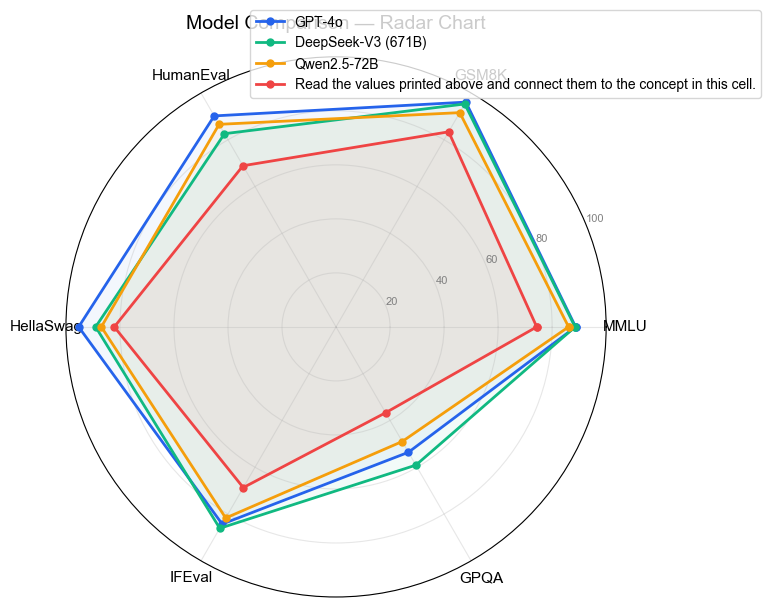

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.


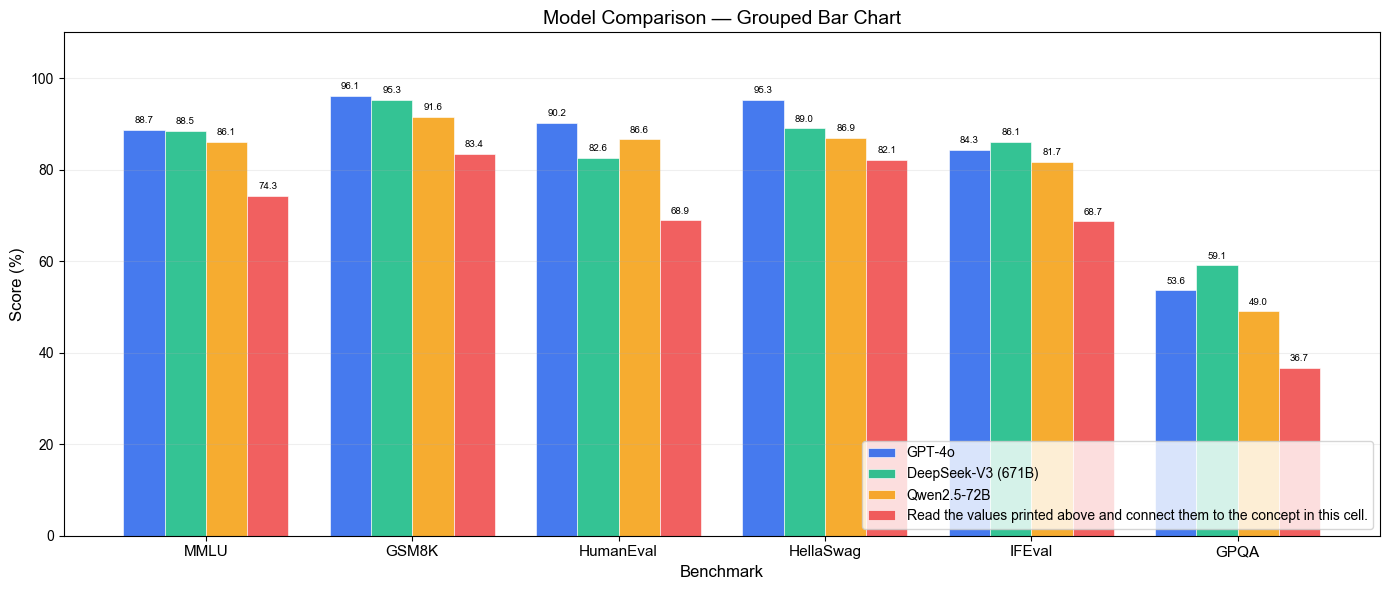

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.


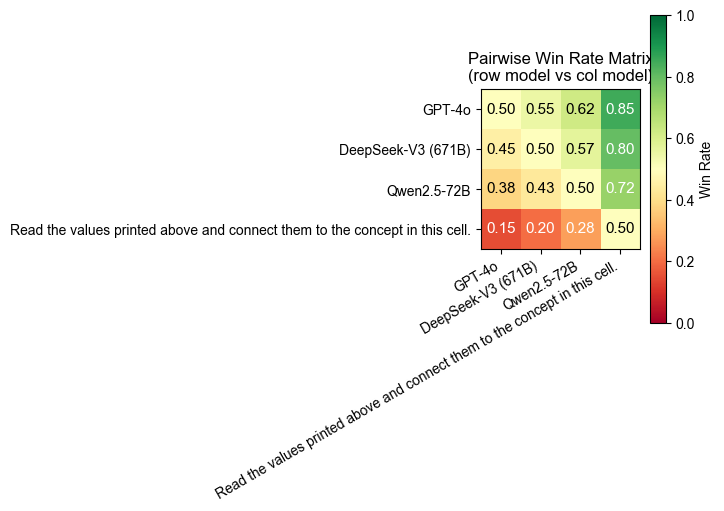

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.


In [8]:
# Teaching note: follow this line to see the main step.
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Teaching note: follow this line to see the main step.
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print('Result:')

# ============================================
# Teaching note: follow this line to see the main step.
# ============================================
# Teaching note: follow this line to see the main step.
radar_models = ["GPT-4o", "DeepSeek-V3 (671B)", "Qwen2.5-72B", 'Read the values printed above and connect them to the concept in this cell.']
radar_datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA"]
radar_colors = ["#2563EB", "#10B981", "#F59E0B", "#EF4444"]

# Teaching note: follow this line to see the main step.
radar_values = []
for model in radar_models:
    vals = [benchmark_results[model][ds] for ds in radar_datasets]
    radar_values.append(vals)

# Teaching note: follow this line to see the main step.
num_vars = len(radar_datasets)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Teaching note: follow this line to see the main step.

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (model, values, color) in enumerate(zip(radar_models, radar_values, radar_colors)):
    values_closed = values + values[:1]
    ax.fill(angles, values_closed, alpha=0.05, color=color)
    ax.plot(angles, values_closed, 'o-', linewidth=2, color=color, label=model, markersize=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_datasets, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8, color='gray')
ax.set_title("Model Comparison — Radar Chart", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

# ============================================
# Teaching note: follow this line to see the main step.
# ============================================
bar_models = radar_models
bar_datasets = radar_datasets

x = np.arange(len(bar_datasets))
width = 0.2
n_models = len(bar_models)

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(bar_models, radar_colors)):
    values = [benchmark_results[model][ds] for ds in bar_datasets]
    offset = width * (i - n_models/2 + 0.5)
    bars = ax.bar(x + offset, values, width, label=model, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    # Teaching note: follow this line to see the main step.
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison — Grouped Bar Chart', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bar_datasets, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

# ============================================
# Teaching note: follow this line to see the main step.
# ============================================
print('Read the values printed above and connect them to the concept in this cell.')
# Teaching note: follow this line to see the main step.
models_for_matrix = ["GPT-4o", "DeepSeek-V3 (671B)", "Qwen2.5-72B", 'Read the values printed above and connect them to the concept in this cell.']
n_mat = len(models_for_matrix)
# Teaching note: follow this line to see the main step.
win_rate_matrix = np.array([
    [0.50, 0.55, 0.62, 0.85],   # GPT-4o vs others
    [0.45, 0.50, 0.57, 0.80],   # DeepSeek-V3
    [0.38, 0.43, 0.50, 0.72],   # Qwen2.5-72B
    [0.15, 0.20, 0.28, 0.50],   # Qwen2.5-7B
])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(win_rate_matrix, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(n_mat))
ax.set_yticks(range(n_mat))
ax.set_xticklabels(models_for_matrix, fontsize=10, rotation=30, ha='right')
ax.set_yticklabels(models_for_matrix, fontsize=10)
ax.set_title('Pairwise Win Rate Matrix\n(row model vs col model)', fontsize=12, fontweight='bold')

# Teaching note: follow this line to see the main step.
for i in range(n_mat):
    for j in range(n_mat):
        color = 'white' if win_rate_matrix[i][j] < 0.3 or win_rate_matrix[i][j] > 0.7 else 'black'
        ax.text(j, i, f'{win_rate_matrix[i][j]:.2f}', ha='center', va='center', fontsize=11, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Win Rate')
plt.tight_layout()
plt.show()

print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

In [9]:
# Teaching note: follow this line to see the main step.
import numpy as np
from scipy import stats

print('Read the values printed above and connect them to the concept in this cell.')

# Teaching note: follow this line to see the main step.
scores = benchmark_results

# Teaching note: follow this line to see the main step.
eval_datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA"]

print('Read the values printed above and connect them to the concept in this cell.')

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print(f"{"'Model'":<22s} {'Avg':>6s} {'Std':>6s}")
print("-" * 36)
for model in scores:
    vals = [scores[model][ds] for ds in eval_datasets]
    avg = np.mean(vals)
    std = np.std(vals)
    print(f"{model:<22s} {avg:>6.1f} {std:>6.1f}")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"{"'Model'":<22s} {'GMean':>6s}")
print("-" * 30)
for model in scores:
    vals = [scores[model][ds] for ds in eval_datasets]
    gmean = stats.gmean(vals)
    print(f"{model:<22s} {gmean:>6.1f}")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
weights = {"MMLU": 0.25, "GSM8K": 0.20, "HumanEval": 0.20, "HellaSwag": 0.10, "IFEval": 0.15, "GPQA": 0.10}
print(f"Read the values printed above and connect them to the concept in this cell.{weights}")
print(f"{"'Model'":<22s} {'Weighted':>8s}")
print("-" * 32)
for model in scores:
    weighted = sum(scores[model][ds] * weights[ds] for ds in eval_datasets)
    print(f"{model:<22s} {weighted:>8.1f}")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
baseline = "GPT-4o"
print(f"{"'Model'":<22s}", end="")
for ds in eval_datasets:
    print(f" {ds:>8s}", end="")
print(f" {'Avg%':>8s}")
print("-" * (22 + 10 * len(eval_datasets) + 8))
for model in scores:
    normalized = [scores[model][ds] / scores[baseline][ds] * 100 for ds in eval_datasets]
    avg_norm = np.mean(normalized)
    print(f"{model:<22s}", end="")
    for nv in normalized:
        print(f" {nv:>8.1f}", end="")
    print(f" {avg_norm:>8.1f}")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
models_list = list(scores.keys())
ranks = {ds: np.argsort([-scores[m][ds] for m in models_list]).argsort() + 1 for ds in eval_datasets}
print(f"{"'Model'":<22s}", end="")
for ds in eval_datasets:
    print(f" {ds:>8s}", end="")
print(f" {'Sum':>6s} {'AvgRank':>8s}")
print("-" * (22 + 10 * len(eval_datasets) + 14))
for i, model in enumerate(models_list):
    rank_list = [ranks[ds][i] for ds in eval_datasets]
    rank_sum = sum(rank_list)
    rank_avg = np.mean(rank_list)
    print(f"{model:<22s}", end="")
    for r in rank_list:
        print(f" {r:>8.0f}", end="")
    print(f" {rank_sum:>6.0f} {rank_avg:>8.1f}")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
'Model'                   Avg    Std
------------------------------------
GPT-4o                   84.7   14.5
DeepSeek-V3 (671B)       83.4   11.5
Qwen2.5-72B              80.3   14.3
Llama-3.1-70B            78.3   14.6
Read the values printed above and connect them to the concept in this cell.   69.0   15.5
Read the values printed above and connect them to the concept in this cell.
'Model'                 GMean
------------------------------
GPT-4o                   83.2
DeepSeek-V3 (671B)       82.5
Qwen2.5-72B              78.7
Llama-3.1-70B            76.6
Read the values printed above and connect them to the concept in this cell.   66.7
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect th

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
|Read the values printed above and connect them to the concept in this cell.| $\frac{1}{N}\sum s_i$ |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| $\frac{1}{N}\sum \frac{s_i}{\max(s_i)}$ |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| $\sum w_i s_i$ |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| $(\prod s_i)^{1/N}$ |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| $\sum rank_i$ |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.

## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
```
1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.3. Read the values printed above and connect them to the concept in this cell.4. Output: Win Rate / LC Win Rate / Avg Length```

### Read the values printed above and connect them to the concept in this cell.
```bash
# Read the values printed above and connect them to the concept in this cell.alpaca_eval evaluate_from_model \
    --model_name_or_path "your-model" \
    --output_path results/your-model \
Read the values printed above and connect them to the concept in this cell.
# Read the values printed above and connect them to the concept in this cell.export OPENAI_API_KEY="sk-xxx"
alpaca_eval evaluate \
    --annotators_config "alpaca_eval_gpt4_turbo_fn" \
    --model_outputs "results/your-model.json" \
    --output_path "results/your-model-eval"

# Read the values printed above and connect them to the concept in this cell.cat results/your-model-eval/leaderboard.csv
```

### Read the values printed above and connect them to the concept in this cell.
```python
from alpaca_eval import evaluate
import pandas as pd

df = evaluate(
    model_outputs="results/your-model-outputs.json",
    annotators_config="alpaca_eval_gpt4_turbo_fn",
    max_instances=100,
)
print(f"Win Rate: {df['win_rate'].iloc[0]:.1%}")
print(f"LC Win Rate: {df['lc_win_rate'].iloc[0]:.1%}")
print(f"Avg Length: {df['avg_length'].iloc[0]:.0f} chars")
```

### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
| **Win Rate** |Read the values printed above and connect them to the concept in this cell.| GPT-4o ≈ 50%, Llama 3 70B ≈ 35% |
| **LC Win Rate** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **Avg Length** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```python
from openai import OpenAI
import json

client = OpenAI(base_url="http://localhost:8000/v1", api_key="not-needed")
with open("alpaca_eval/prompts/alpaca_eval.json") as f:
    prompts = json.load(f)

outputs = []
Read the values printed above and connect them to the concept in this cell.    resp = client.chat.completions.create(
        model="your-model",
        messages=[{"role": "user", "content": item["instruction"]}],
        temperature=0,
        max_tokens=1024,
    )
    outputs.append({
        "instruction": item["instruction"],
        "output": resp.choices[0].message.content,
        "generator": "your-model",
    })

with open("results/your-model-outputs.json", "w") as f:
    json.dump(outputs, f, ensure_ascii=False, indent=2)
Read the values printed above and connect them to the concept in this cell.```

## Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
|Read the values printed above and connect them to the concept in this cell.| Context Precision / Recall |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| NDCG / MRR |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| Answer Relevance |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.| Noise Sensitivity |Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.```bash
Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.
### 10.2 codeModelevaluation — pass@k vs pass^k
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
| **pass@1** |Exercise passed: you have understood this step.|Read the values printed above and connect them to the concept in this cell.|
| **pass@k** |Exercise passed: you have understood this step.|Read the values printed above and connect them to the concept in this cell.|
| **pass^k** |Exercise passed: you have understood this step.|Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.

## Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
| **Position Bias** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **Length Bias** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **Egocentric Bias** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **Verbosity Bias** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
| **CR@K (Consistency Rate)** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **Prompt Robustness** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **Order Robustness** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **Sampling Robustness** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

## Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|:---|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| `acc` / `acc_norm` | MMLU, HellaSwag, ARC |
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| `exact_match` / `pass@k` / `F1` | GSM8K, HumanEval |
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| `win_rate` / `Elo` / `score` | MT-Bench, AlpacaEval |
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| `strict_acc` | IFEval |
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| `ppl` / `bpb` | WikiText, Lambada |

### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
| **IFEval strict** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **GPQA** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **AIME pass@1** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **SWE-bench** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **LiveCodeBench** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **RULER** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

### Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.└── Agent    → SWE-bench + WebArena + ToolBench
```

## Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Note|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|:---|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Note|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| `--model_args seed=42` |
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| `temperature=0` |
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Note|
|:---|:---|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

## Read the values printed above and connect them to the concept in this cell.
```bash
# Read the values printed above and connect them to the concept in this cell.# installpip install lm-eval openai

# Read the values printed above and connect them to the concept in this cell.lm_eval --model local-chat-completions \
    --model_args model=deepseek-chat,base_url=https://api.deepseek.com/v1/chat/completions,token=$DEEPSEEK_API_KEY,num_concurrent=4,tokenized_requests=False \
    --tasks gsm8k --batch_size 8 --limit 50 \
    --output_path ./eval_results/

# Read the values printed above and connect them to the concept in this cell.lm_eval --model local-completions \
    --model_args model=Qwen2.5-7B-Instruct,base_url=http://localhost:8000/v1/completions,num_concurrent=4,tokenized_requests=False \
    --tasks mmlu --batch_size 16 --limit 100 \
    --output_path ./eval_results/

# Read the values printed above and connect them to the concept in this cell.lm_eval --model hf \
    --model_args pretrained=Qwen/Qwen2.5-7B-Instruct,dtype=bfloat16 \
    --tasks gsm8k,mmlu,hellaswag --batch_size auto \
    --output_path ./eval_results/

# Read the values printed above and connect them to the concept in this cell.lm_eval --tasks list | head -30

# Read the values printed above and connect them to the concept in this cell.# from lm_eval import simple_evaluate# results = simple_evaluate(#     model='local-chat-completions',#     model_args='model=deepseek-chat,base_url=...,token=...',#     tasks=['gsm8k', 'ifeval'],#     limit=50,# )```

---

## Read the values printed above and connect them to the concept in this cell.
### Read the values printed above and connect them to the concept in this cell.
| # |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|:---|:---|:---|
| 1 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| 2 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| 3 | OpenAI-Compatible API |Read the values printed above and connect them to the concept in this cell.|
| 4 | LLM-as-Judge |Read the values printed above and connect them to the concept in this cell.|
| 5 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| 6 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| 7 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| 8 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| 9 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| 10 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| 11 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

### Read the values printed above and connect them to the concept in this cell.
```bash
# Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.git clone https://github.com/lm-sys/FastChat.git                    # MT-Bench + Chatbot Arena

# Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

### Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.  1. pip install lm-eval openai  2. Read the values printed above and connect them to the concept in this cell.  3. Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  1. Read the values printed above and connect them to the concept in this cell.  2. Read the values printed above and connect them to the concept in this cell.  3. Read the values printed above and connect them to the concept in this cell.  4. Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  1. Read the values printed above and connect them to the concept in this cell.  2. Read the values printed above and connect them to the concept in this cell.  3. Read the values printed above and connect them to the concept in this cell.```

### Quick reference
|Read the values printed above and connect them to the concept in this cell.|One-line explanation|
|:---|:---|
| **loglikelihood vs generate_until** |Read the values printed above and connect them to the concept in this cell.|
| **pass@k vs pass^k** |Read the values printed above and connect them to the concept in this cell.|
| **LC Win Rate** |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **CR@K** |Read the values printed above and connect them to the concept in this cell.|
| **Position / Length / Egocentric Bias** |Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.